In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from tqdm import tqdm
from scipy.stats import gaussian_kde
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

In [2]:
DATA_ROOT = Path("./two_class_cifar_full")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("Data root:", DATA_ROOT.resolve())

Using device: cuda
Data root: /home/amyliu/Desktop/GR/two_class_cifar_full


In [3]:
image_paths = []
labels = []

label_names = ["cat", "dog"]

for split in ["train", "test"]:
    for label in label_names:
        folder = DATA_ROOT / split / label
        for img_path in sorted(folder.glob("*.png")):
            image_paths.append(img_path)
            labels.append(label)

print("Total images:", len(image_paths))
print(pd.Series(labels).value_counts())

Total images: 12000
cat    6000
dog    6000
Name: count, dtype: int64


In [4]:
weights = EfficientNet_B0_Weights.DEFAULT
efficientnet = models.efficientnet_b0(weights=weights).to(device)
efficientnet.eval()

preprocess = weights.transforms()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/amyliu/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 71.9MB/s]


In [5]:
class EfficientNetFeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.features = model.features
        self.avgpool = model.avgpool

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)   # shape: (B, 1280)
        return x

feature_extractor = EfficientNetFeatureExtractor(efficientnet).to(device)
feature_extractor.eval()

EfficientNetFeatureExtractor(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): C

In [6]:
efficientnet_embeddings = []
metadata_rows = []

with torch.no_grad():
    for img_path, label in tqdm(list(zip(image_paths, labels)), total=len(image_paths)):
        image = Image.open(img_path).convert("RGB")
        img_tensor = preprocess(image).unsqueeze(0).to(device)

        feat = feature_extractor(img_tensor)     # (1, 1280)
        feat = feat.squeeze(0).cpu().numpy()     # (1280,)

        efficientnet_embeddings.append(feat)
        metadata_rows.append({
            "filename": img_path.name,
            "label": label,
            "split": img_path.parent.parent.name,
            "path": str(img_path)
        })

efficientnet_embeddings = np.array(efficientnet_embeddings)
efficientnet_meta = pd.DataFrame(metadata_rows)

print("Embedding shape:", efficientnet_embeddings.shape)
print(efficientnet_meta.head())

100%|██████████| 12000/12000 [00:50<00:00, 237.05it/s]

Embedding shape: (12000, 1280)
        filename label  split                                          path
0  cat_00000.png   cat  train  two_class_cifar_full/train/cat/cat_00000.png
1  cat_00001.png   cat  train  two_class_cifar_full/train/cat/cat_00001.png
2  cat_00002.png   cat  train  two_class_cifar_full/train/cat/cat_00002.png
3  cat_00003.png   cat  train  two_class_cifar_full/train/cat/cat_00003.png
4  cat_00004.png   cat  train  two_class_cifar_full/train/cat/cat_00004.png


In [7]:
OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.save(OUTPUT_DIR / "efficientnet_b0_embeddings_cat_dog.npy", efficientnet_embeddings)
efficientnet_meta.to_csv(OUTPUT_DIR / "efficientnet_b0_metadata_cat_dog.csv", index=False)

print("Saved embedding and metadata.")

Saved embedding and metadata.


In [8]:
sim_matrix = cosine_similarity(efficientnet_embeddings)
n = len(efficientnet_meta)

all_sims = []
same_sims = []
cross_sims = []
pair_rows = []

for i in range(n):
    for j in range(i + 1, n):
        sim = sim_matrix[i, j]
        label_i = efficientnet_meta.loc[i, "label"]
        label_j = efficientnet_meta.loc[j, "label"]

        all_sims.append(sim)

        if label_i == label_j:
            same_sims.append(sim)
            pair_type = "same"
        else:
            cross_sims.append(sim)
            pair_type = "cross"

        pair_rows.append({
            "idx1": i,
            "idx2": j,
            "file1": efficientnet_meta.loc[i, "filename"],
            "file2": efficientnet_meta.loc[j, "filename"],
            "label1": label_i,
            "label2": label_j,
            "pair_type": pair_type,
            "cosine_similarity": sim
        })

all_sims = np.array(all_sims)
same_sims = np.array(same_sims)
cross_sims = np.array(cross_sims)

efficientnet_pair_df = pd.DataFrame(pair_rows)
efficientnet_pair_df.to_csv(OUTPUT_DIR / "efficientnet_b0_pairwise_similarity.csv", index=False)

print("All pairs:", len(all_sims))
print("Same pairs:", len(same_sims))
print("Cross pairs:", len(cross_sims))
print("Mean all:", all_sims.mean())
print("Mean same:", same_sims.mean())
print("Mean cross:", cross_sims.mean())

All pairs: 71994000
Same pairs: 35994000
Cross pairs: 36000000
Mean all: 0.37656036
Mean same: 0.39887527
Mean cross: 0.35424918


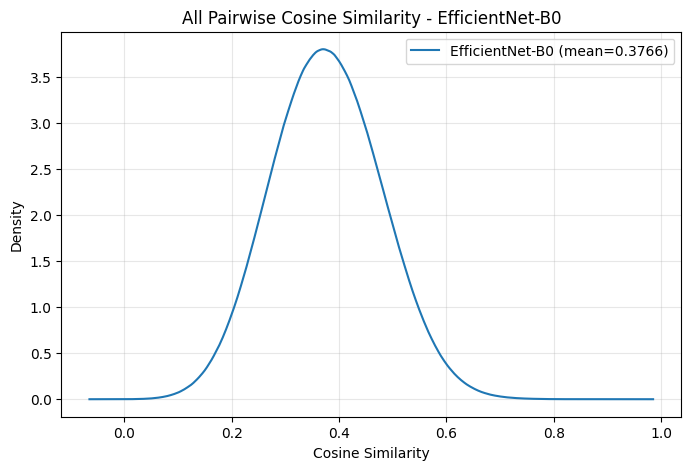

In [9]:
x_grid = np.linspace(all_sims.min(), all_sims.max(), 500)
pdf_all = gaussian_kde(all_sims)(x_grid)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, pdf_all, label=f"EfficientNet-B0 (mean={all_sims.mean():.4f})")
plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.title("All Pairwise Cosine Similarity - EfficientNet-B0")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

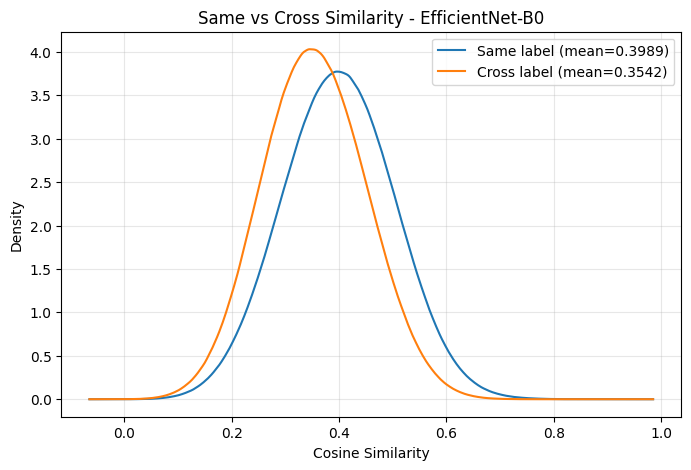

In [10]:
x_min = min(same_sims.min(), cross_sims.min())
x_max = max(same_sims.max(), cross_sims.max())
x_grid = np.linspace(x_min, x_max, 500)

pdf_same = gaussian_kde(same_sims)(x_grid)
pdf_cross = gaussian_kde(cross_sims)(x_grid)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, pdf_same, label=f"Same label (mean={same_sims.mean():.4f})")
plt.plot(x_grid, pdf_cross, label=f"Cross label (mean={cross_sims.mean():.4f})")
plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.title("Same vs Cross Similarity - EfficientNet-B0")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
def compute_hist(data, bins, value_range):
    hist, _ = np.histogram(data, bins=bins, range=value_range)
    hist = hist.astype(float)
    hist += 1e-8
    hist /= hist.sum()
    return hist

def chi_square_distance(p, q):
    return np.sum((p - q) ** 2 / (p + q))

def bootstrap_chi_square(group1, group2, bins=30, n_boot=1000, random_state=42):
    rng = np.random.default_rng(random_state)

    n = min(len(group1), len(group2))
    global_min = min(group1.min(), group2.min())
    global_max = max(group1.max(), group2.max())
    value_range = (global_min, global_max)

    distances = []

    for _ in range(n_boot):
        sample1 = rng.choice(group1, size=n, replace=True)
        sample2 = rng.choice(group2, size=n, replace=True)

        hist1 = compute_hist(sample1, bins=bins, value_range=value_range)
        hist2 = compute_hist(sample2, bins=bins, value_range=value_range)

        dist = chi_square_distance(hist1, hist2)
        distances.append(dist)

    distances = np.array(distances)

    return {
        "mean_distance": distances.mean(),
        "std_distance": distances.std(ddof=1),
        "ci_lower": np.percentile(distances, 2.5),
        "ci_upper": np.percentile(distances, 97.5),
        "all_distances": distances
    }

In [12]:
efficientnet_result = bootstrap_chi_square(
    same_sims,
    cross_sims,
    bins=30,
    n_boot=1000,
    random_state=42
)

print("EfficientNet-B0")
print(f"Mean chi-square distance: {efficientnet_result['mean_distance']:.6f}")
print(f"Std: {efficientnet_result['std_distance']:.6f}")
print(f"95% CI: [{efficientnet_result['ci_lower']:.6f}, {efficientnet_result['ci_upper']:.6f}]")

EfficientNet-B0
Mean chi-square distance: 0.096298
Std: 0.000096
95% CI: [0.096103, 0.096480]


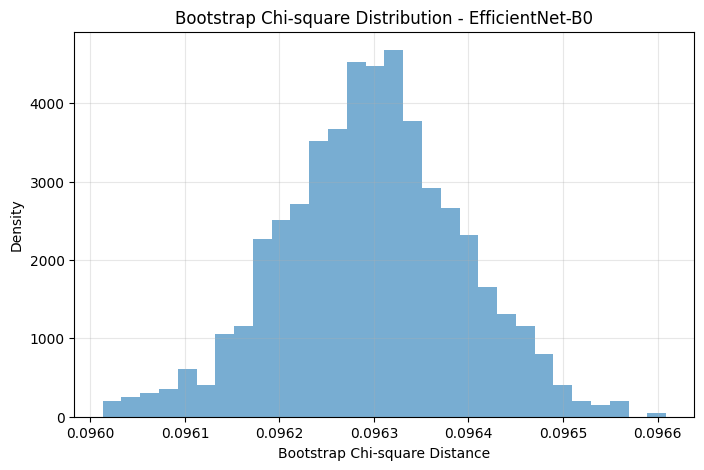

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(efficientnet_result["all_distances"], bins=30, density=True, alpha=0.6)
plt.xlabel("Bootstrap Chi-square Distance")
plt.ylabel("Density")
plt.title("Bootstrap Chi-square Distribution - EfficientNet-B0")
plt.grid(True, alpha=0.3)
plt.show()